# Lecture 18: Xarray cont.

## Recap: Data structures


We'll start by reviewing the various components of the Xarray data model, represented here visually:

<img src="https://docs.xarray.dev/en/stable/_images/dataset-diagram.png" align="center" width="60%">

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import xarray as xr

ds = xr.tutorial.load_dataset("air_temperature")

In [2]:
print(ds)

<xarray.Dataset> Size: 31MB
Dimensions:  (lat: 25, time: 2920, lon: 53)
Coordinates:
  * lat      (lat) float32 100B 75.0 72.5 70.0 67.5 65.0 ... 22.5 20.0 17.5 15.0
  * lon      (lon) float32 212B 200.0 202.5 205.0 207.5 ... 325.0 327.5 330.0
  * time     (time) datetime64[ns] 23kB 2013-01-01 ... 2014-12-31T18:00:00
Data variables:
    air      (time, lat, lon) float64 31MB 241.2 242.5 243.5 ... 296.2 295.7
Attributes:
    Conventions:  COARDS
    title:        4x daily NMC reanalysis (1948)
    description:  Data is from NMC initialized reanalysis\n(4x/day).  These a...
    platform:     Model
    references:   http://www.esrl.noaa.gov/psd/data/gridded/data.ncep.reanaly...


## Why Xarray? 

Metadata provides context and provides code that is more legible. This reduces the likelihood of errors from typos and makes analysis more intuitive and fun!

### Analysis without xarray: 

In [ ]:
# plot the first timestep
lat = ds.air.lat.data  # numpy array
lon = ds.air.lon.data  # numpy array
temp = ds.air.data  # numpy array

In [ ]:
plt.figure()
plt.pcolormesh(lon, lat, temp[0, :, :]);

In [ ]:
temp.mean(axis=1)  ## what did I just do? I can't tell by looking at this line.

### Analysis with xarray

Much more readable:

In [ ]:
ds.air.isel(time=0).plot(x="lon");

Use dimension names instead of axis numbers


In [ ]:
ds.air.mean(dim="time").plot(x="lon")

### Indexing

Xarray inherits its label-based indexing rules from pandas so should be very familiar


In [3]:
# pull out data for all of 2013-May
ds.sel(time="2013-05")

<xarray.Dataset> Size: 1MB
Dimensions:  (lat: 25, time: 124, lon: 53)
Coordinates:
  * lat      (lat) float32 100B 75.0 72.5 70.0 67.5 65.0 ... 22.5 20.0 17.5 15.0
  * lon      (lon) float32 212B 200.0 202.5 205.0 207.5 ... 325.0 327.5 330.0
  * time     (time) datetime64[ns] 992B 2013-05-01 ... 2013-05-31T18:00:00
Data variables:
    air      (time, lat, lon) float64 1MB 259.2 259.3 259.1 ... 297.6 297.5
Attributes:
    Conventions:  COARDS
    title:        4x daily NMC reanalysis (1948)
    description:  Data is from NMC initialized reanalysis\n(4x/day).  These a...
    platform:     Model
    references:   http://www.esrl.noaa.gov/psd/data/gridded/data.ncep.reanaly...

In [4]:
# pull out time index 0, lat index 2, and lon index 3
ds.air.isel(time=0, lat=2, lon=3)  #  much better than ds.air[0, 2, 3]

<xarray.DataArray 'air' ()> Size: 8B
array(247.5)
Coordinates:
    lat      float32 4B 70.0
    lon      float32 4B 207.5
    time     datetime64[ns] 8B 2013-01-01
Attributes:
    long_name:     4xDaily Air temperature at sigma level 995
    units:         degK
    precision:     2
    GRIB_id:       11
    GRIB_name:     TMP
    var_desc:      Air temperature
    dataset:       NMC Reanalysis
    level_desc:    Surface
    statistic:     Individual Obs
    parent_stat:   Other
    actual_range:  [185.16 322.1 ]

## Exercise 1

Load the air temperature dataset and plot a time-series of the temperature in San Diego (latitude 32.7157°N and longitude 117.1611°W). 


In [ ]:
ds.air.sel(lat=32.7157, lon=242.8389, method='nearest').plot()

Now try using linear interpolation, does it make a difference?

In [ ]:
ds.air.interp(lat=32.7157, lon=242.8389, method='linear').plot()

## Concepts for computation

Consider calculating the *mean air temperature per unit surface area* for this dataset. 

Because latitude and longitude correspond to spherical coordinates for Earth's surface, each 2.5x2.5 degree grid cell actually has a different surface area as you move away from the equator! 

This is because *latitudinal length* is fixed ($ \delta Lat = R \delta \phi  $), but *longitudinal length varies with latitude* ($ \delta Lon = R \delta \lambda \cos(\phi) $)


So the [area element for lat-lon coordinates](https://en.wikipedia.org/wiki/Spherical_coordinate_system#Integration_and_differentiation_in_spherical_coordinates) is


$$ \delta A = R^2 \delta\phi \, \delta\lambda \cos(\phi) $$

where $\phi$ is latitude, $\delta \phi$ is the spacing of the points in latitude, $\delta \lambda$ is the spacing of the points in longitude, and $R$ is Earth's radius. (In this formula, $\phi$ and $\lambda$ are measured in radians)

In [5]:
# Earth's average radius in meters
R = 6.371e6

# Coordinate spacing for this dataset is 2.5 x 2.5 degrees
dϕ = np.deg2rad(2.5)
dλ = np.deg2rad(2.5)

dlat = R * dϕ * xr.ones_like(ds.air.lon)
dlon = R * dλ * np.cos(np.deg2rad(ds.air.lat))

There are two concepts here:
1. you can call functions like `np.cos` and `np.deg2rad` (["numpy ufuncs"](https://numpy.org/doc/stable/reference/ufuncs.html)) on Xarray objects and receive an Xarray object back.
2. We used [ones_like](https://docs.xarray.dev/en/stable/generated/xarray.ones_like.html) to create a DataArray that looks like `ds.air.lon` in all respects, except that the data are all ones

In [6]:
# returns an xarray DataArray!
np.cos(np.deg2rad(ds.lat))

<xarray.DataArray 'lat' (lat: 25)> Size: 100B
array([0.25881907, 0.30070582, 0.34202015, 0.38268346, 0.42261827,
       0.4617486 , 0.49999997, 0.5372996 , 0.57357645, 0.6087614 ,
       0.6427876 , 0.67559016, 0.70710677, 0.7372773 , 0.76604444,
       0.7933533 , 0.81915206, 0.8433914 , 0.8660254 , 0.8870108 ,
       0.90630776, 0.9238795 , 0.9396926 , 0.95371693, 0.9659258 ],
      dtype=float32)
Coordinates:
  * lat      (lat) float32 100B 75.0 72.5 70.0 67.5 65.0 ... 22.5 20.0 17.5 15.0
Attributes:
    standard_name:  latitude
    long_name:      Latitude
    units:          degrees_north
    axis:           Y

In [7]:
# cell latitude length is constant with longitude
dlat

<xarray.DataArray 'lon' (lon: 53)> Size: 424B
array([277987.3166114, 277987.3166114, 277987.3166114, 277987.3166114,
       277987.3166114, 277987.3166114, 277987.3166114, 277987.3166114,
       277987.3166114, 277987.3166114, 277987.3166114, 277987.3166114,
       277987.3166114, 277987.3166114, 277987.3166114, 277987.3166114,
       277987.3166114, 277987.3166114, 277987.3166114, 277987.3166114,
       277987.3166114, 277987.3166114, 277987.3166114, 277987.3166114,
       277987.3166114, 277987.3166114, 277987.3166114, 277987.3166114,
       277987.3166114, 277987.3166114, 277987.3166114, 277987.3166114,
       277987.3166114, 277987.3166114, 277987.3166114, 277987.3166114,
       277987.3166114, 277987.3166114, 277987.3166114, 277987.3166114,
       277987.3166114, 277987.3166114, 277987.3166114, 277987.3166114,
       277987.3166114, 277987.3166114, 277987.3166114, 277987.3166114,
       277987.3166114, 277987.3166114, 277987.3166114, 277987.3166114,
       277987.3166114])
Coordinates:
  * lon      (lon) float32 212B 200.0 202.5 205.0 207.5 ... 325.0 327.5 330.0
Attributes:
    standard_name:  longitude
    long_name:      Longitude
    units:          degrees_east
    axis:           X

In [8]:
# cell longitude length changes with latitude
dlon

<xarray.DataArray 'lat' (lat: 25)> Size: 200B
array([ 71948.41971306,  83592.40408075,  95077.26483729, 106381.14702947,
       117482.51880611, 128360.25426477, 138993.65002103, 149362.46663188,
       159446.9783037 , 169227.95632292, 178686.79332603, 187805.49501496,
       196566.71329567, 204953.74627825, 212950.63769282, 220542.16032028,
       227713.88226964, 234452.11726995, 240744.07379441, 246577.75564428,
       251942.06136494, 256826.78424588, 261222.62889001, 265121.21121369,
       268515.12472406])
Coordinates:
  * lat      (lat) float32 100B 75.0 72.5 70.0 67.5 65.0 ... 22.5 20.0 17.5 15.0
Attributes:
    standard_name:  latitude
    long_name:      Latitude
    units:          degrees_north
    axis:           Y

### Broadcasting: expanding data

Our longitude and latitude length DataArrays are both 1D with different dimension names. If we multiple these DataArrays together the dimensionality is expanded to 2D by _broadcasting_:

In [9]:
cell_area = dlon * dlat
cell_area

<xarray.DataArray (lat: 25, lon: 53)> Size: 11kB
array([[2.00007481e+10, 2.00007481e+10, 2.00007481e+10, ...,
        2.00007481e+10, 2.00007481e+10, 2.00007481e+10],
       [2.32376281e+10, 2.32376281e+10, 2.32376281e+10, ...,
        2.32376281e+10, 2.32376281e+10, 2.32376281e+10],
       [2.64302737e+10, 2.64302737e+10, 2.64302737e+10, ...,
        2.64302737e+10, 2.64302737e+10, 2.64302737e+10],
       ...,
       [7.26165776e+10, 7.26165776e+10, 7.26165776e+10, ...,
        7.26165776e+10, 7.26165776e+10, 7.26165776e+10],
       [7.37003341e+10, 7.37003341e+10, 7.37003341e+10, ...,
        7.37003341e+10, 7.37003341e+10, 7.37003341e+10],
       [7.46437990e+10, 7.46437990e+10, 7.46437990e+10, ...,
        7.46437990e+10, 7.46437990e+10, 7.46437990e+10]])
Coordinates:
  * lat      (lat) float32 100B 75.0 72.5 70.0 67.5 65.0 ... 22.5 20.0 17.5 15.0
  * lon      (lon) float32 212B 200.0 202.5 205.0 207.5 ... 325.0 327.5 330.0

The result has two dimensions because xarray realizes that dimensions `lon` and
`lat` are different so it automatically broadcasts to get a 2D result. 

<img src="https://jakevdp.github.io/PythonDataScienceHandbook/figures/02.05-broadcasting.png" align="center">

Note, because xarray knows about dimension names we avoid having to create unnecessary
size-1 dimensions using `np.newaxis` or `.reshape`. For more, see the [user guide](https://docs.xarray.dev/en/stable/user-guide/computation.html#broadcasting-by-dimension-name)


### Alignment: putting data on the same grid

When doing arithmetic operations xarray automatically "aligns" i.e. puts the
data on the same grid. In this case `cell_area` and `ds.air` are at the same
lat, lon points we end up with a result with the same shape (25x53):


In [ ]:
ds.air.isel(time=1) / cell_area

Now lets make `cell_area` unaligned i.e. change the coordinate labels


In [ ]:
# make a copy of cell_area
# then add 1e-5 degrees to latitude
cell_area_bad = cell_area.copy(deep=True)
cell_area_bad["lat"] = cell_area.lat + 1e-5  # latitudes are off by 1e-5 degrees!
cell_area_bad

In [ ]:
cell_area_bad * ds.air.isel(time=1)

The result is an empty array with no latitude coordinates because none of them were aligned!

**Tip:** If you notice extra NaNs or missing points after xarray computation, it
means that your xarray coordinates were not aligned _exactly_.

For more, see
[the Xarray documentation](https://docs.xarray.dev/en/stable/user-guide/computation.html#automatic-alignment). [This tutorial notebook](https://tutorial.xarray.dev/fundamentals/02.3_aligning_data_objects.html) also covers alignment and broadcasting


## High level computation 

(`groupby`, `resample`, `rolling`, `coarsen`, `weighted`)

Xarray has some very useful high level objects that let you do common
computations:

1. `weighted` :
   [Weight your data before reducing](https://docs.xarray.dev/en/stable/user-guide/computation.html#weighted-array-reductions)
1. `resample` :
   [Groupby specialized for time axes. Either downsample or upsample your data.](https://docs.xarray.dev/en/stable/user-guide/time-series.html#resampling-and-grouped-operations)
1. `rolling` :
   [Operate on rolling windows of your data e.g. running mean](https://docs.xarray.dev/en/stable/user-guide/computation.html#rolling-window-operations)
1. `coarsen` :
   [Downsample your data](https://docs.xarray.dev/en/stable/user-guide/computation.html#coarsen-large-arrays)
1. `groupby` :
   [Bin data in to groups and reduce](https://docs.xarray.dev/en/stable/groupby.html)


Below we quickly demonstrate these patterns. See the user guide links above and [the tutorial](https://tutorial.xarray.dev/intermediate/01-high-level-computation-patterns.html) for more.

### weighted


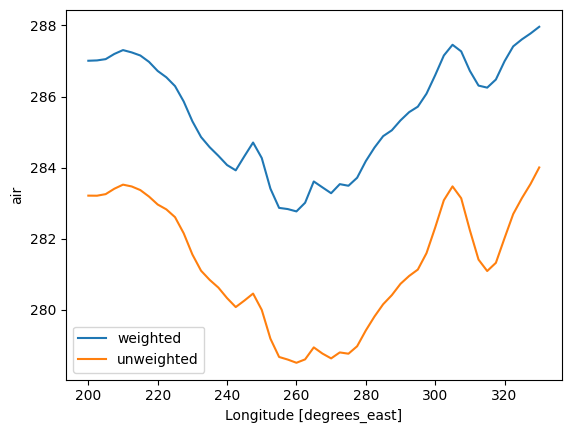

In [10]:
# weight by cell_area and take mean over (time, lon)
ds.weighted(cell_area).mean(["lat", "time"]).air.plot(x="lon", label='weighted');
ds.mean(["lat", "time"]).air.plot(x="lon", label='unweighted');
plt.legend()

### groupby


In [11]:
# here's ds
ds

<xarray.Dataset> Size: 31MB
Dimensions:  (lat: 25, time: 2920, lon: 53)
Coordinates:
  * lat      (lat) float32 100B 75.0 72.5 70.0 67.5 65.0 ... 22.5 20.0 17.5 15.0
  * lon      (lon) float32 212B 200.0 202.5 205.0 207.5 ... 325.0 327.5 330.0
  * time     (time) datetime64[ns] 23kB 2013-01-01 ... 2014-12-31T18:00:00
Data variables:
    air      (time, lat, lon) float64 31MB 241.2 242.5 243.5 ... 296.2 295.7
Attributes:
    Conventions:  COARDS
    title:        4x daily NMC reanalysis (1948)
    description:  Data is from NMC initialized reanalysis\n(4x/day).  These a...
    platform:     Model
    references:   http://www.esrl.noaa.gov/psd/data/gridded/data.ncep.reanaly...

In [12]:
# seasonal groups
ds.groupby("time.season")

DatasetGroupBy, grouped over 'season'
4 groups with labels 'DJF', 'JJA', 'MAM', 'SON'.

In [34]:
# make a seasonal mean
seasonal_mean = ds.groupby("time.season").mean()
seasonal_mean

<xarray.Dataset> Size: 43kB
Dimensions:  (season: 4, lat: 25, lon: 53)
Coordinates:
  * lat      (lat) float32 100B 75.0 72.5 70.0 67.5 65.0 ... 22.5 20.0 17.5 15.0
  * lon      (lon) float32 212B 200.0 202.5 205.0 207.5 ... 325.0 327.5 330.0
  * season   (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'
Data variables:
    air      (season, lat, lon) float64 42kB 247.0 247.0 246.7 ... 299.4 299.5
Attributes:
    Conventions:  COARDS
    title:        4x daily NMC reanalysis (1948)
    description:  Data is from NMC initialized reanalysis\n(4x/day).  These a...
    platform:     Model
    references:   http://www.esrl.noaa.gov/psd/data/gridded/data.ncep.reanaly...

The seasons are out of order (they are alphabetically sorted). This is a common
annoyance. The solution is to use `.sel` to change the order of labels


In [14]:
seasonal_mean = seasonal_mean.sel(season=["DJF", "MAM", "JJA", "SON"])
seasonal_mean

<xarray.Dataset> Size: 43kB
Dimensions:  (season: 4, lat: 25, lon: 53)
Coordinates:
  * lat      (lat) float32 100B 75.0 72.5 70.0 67.5 65.0 ... 22.5 20.0 17.5 15.0
  * lon      (lon) float32 212B 200.0 202.5 205.0 207.5 ... 325.0 327.5 330.0
  * season   (season) object 32B 'DJF' 'MAM' 'JJA' 'SON'
Data variables:
    air      (season, lat, lon) float64 42kB 247.0 247.0 246.7 ... 299.4 299.5
Attributes:
    Conventions:  COARDS
    title:        4x daily NMC reanalysis (1948)
    description:  Data is from NMC initialized reanalysis\n(4x/day).  These a...
    platform:     Model
    references:   http://www.esrl.noaa.gov/psd/data/gridded/data.ncep.reanaly...

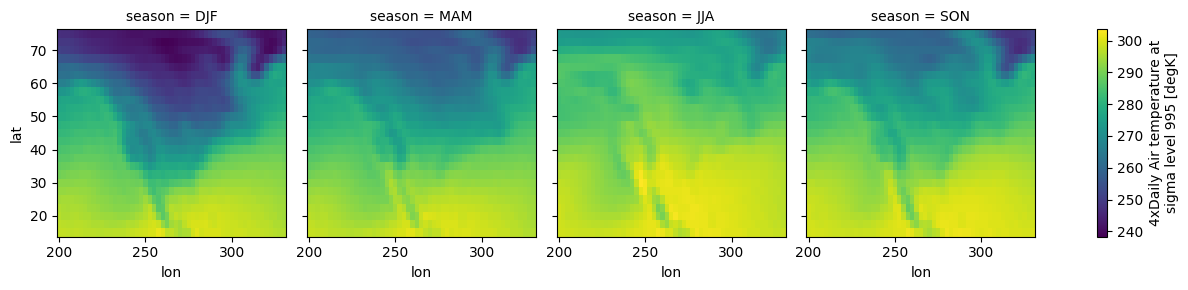

In [15]:
seasonal_mean.air.plot(col="season")

### resample


In [17]:
# resample to monthly frequency
ds.resample(time="ME").mean()

<xarray.Dataset> Size: 255kB
Dimensions:  (time: 24, lat: 25, lon: 53)
Coordinates:
  * lat      (lat) float32 100B 75.0 72.5 70.0 67.5 65.0 ... 22.5 20.0 17.5 15.0
  * lon      (lon) float32 212B 200.0 202.5 205.0 207.5 ... 325.0 327.5 330.0
  * time     (time) datetime64[ns] 192B 2013-01-31 2013-02-28 ... 2014-12-31
Data variables:
    air      (time, lat, lon) float64 254kB 244.5 244.7 244.7 ... 297.7 297.7
Attributes:
    Conventions:  COARDS
    title:        4x daily NMC reanalysis (1948)
    description:  Data is from NMC initialized reanalysis\n(4x/day).  These a...
    platform:     Model
    references:   http://www.esrl.noaa.gov/psd/data/gridded/data.ncep.reanaly...

## Visualization

(`.plot`)


We have seen very simple plots earlier. Xarray also lets you easily visualize
3D and 4D datasets by presenting multiple facets (or panels or subplots) showing
variations across rows and/or columns.

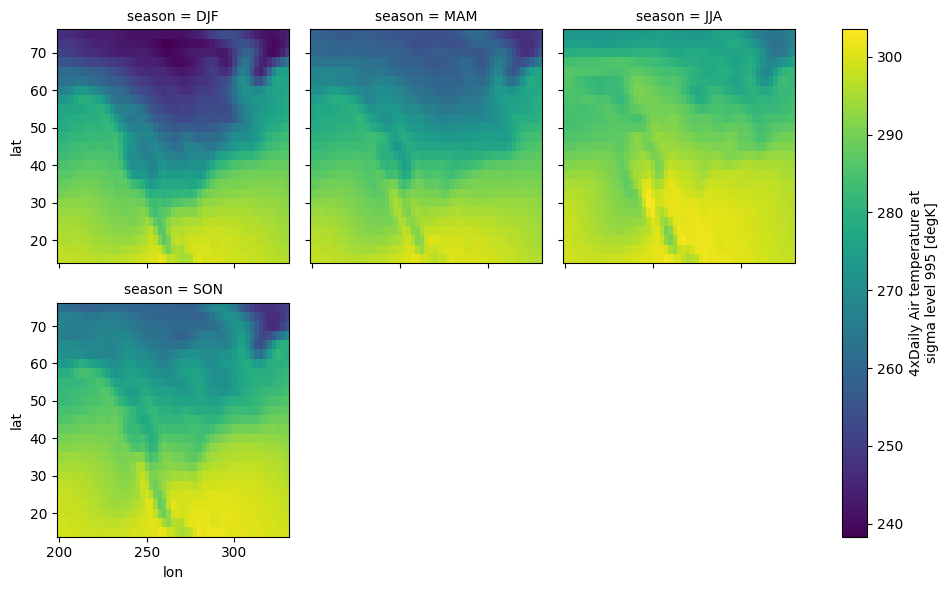

In [19]:
# facet the seasonal_mean
seasonal_mean.air.plot(col="season", col_wrap=3);

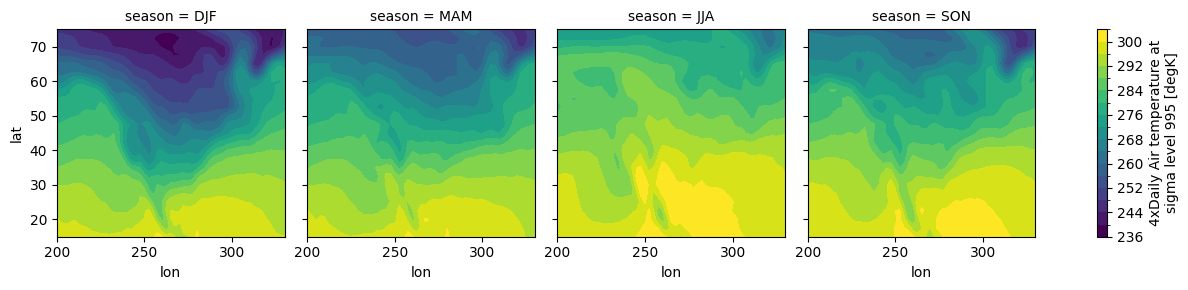

In [21]:
# contours
seasonal_mean.air.plot.contourf(col="season", levels=20, add_colorbar=True);

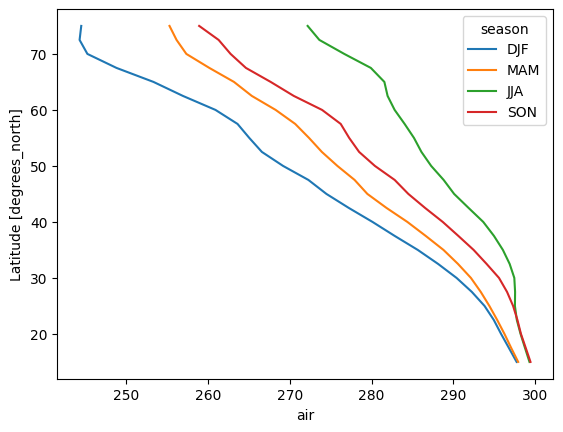

In [22]:
seasonal_mean.air.mean("lon").plot.line(hue="season", y="lat");

For more see the [user guide](https://docs.xarray.dev/en/stable/plotting.html), the [gallery](https://docs.xarray.dev/en/stable/examples/visualization_gallery.html), and [the tutorial material](https://tutorial.xarray.dev/fundamentals/04.0_plotting.html).

## Reading and writing files

Xarray supports many disk formats. Below is a small example using netCDF. For
more see the [documentation](https://docs.xarray.dev/en/stable/user-guide/io.html)


In [23]:
# write to netCDF
ds.to_netcdf("my-example-dataset.nc")

/var/folders/x3/vhgm155938j8q97fv4kz3mv80000gn/T/ipykernel_50823/1659397704.py:2: SerializationWarning: saving variable air with floating point data as an integer dtype without any _FillValue to use for NaNs
  ds.to_netcdf("my-example-dataset.nc")


```{note}
To avoid the `SerializationWarning` you can assign a _FillValue for any NaNs in 'air' array by adding the keyword argument encoding=dict(air={_FillValue=-9999})
```

In [24]:
# read from disk
fromdisk = xr.open_dataset("my-example-dataset.nc")
fromdisk 

<xarray.Dataset> Size: 31MB
Dimensions:  (lat: 25, time: 2920, lon: 53)
Coordinates:
  * lat      (lat) float32 100B 75.0 72.5 70.0 67.5 65.0 ... 22.5 20.0 17.5 15.0
  * lon      (lon) float32 212B 200.0 202.5 205.0 207.5 ... 325.0 327.5 330.0
  * time     (time) datetime64[ns] 23kB 2013-01-01 ... 2014-12-31T18:00:00
Data variables:
    air      (time, lat, lon) float64 31MB ...
Attributes:
    Conventions:  COARDS
    title:        4x daily NMC reanalysis (1948)
    description:  Data is from NMC initialized reanalysis\n(4x/day).  These a...
    platform:     Model
    references:   http://www.esrl.noaa.gov/psd/data/gridded/data.ncep.reanaly...

**Tip:** A common use case to read datasets that are a collection of many netCDF
files. See the [documentation](https://docs.xarray.dev/en/stable/user-guide/io.html#reading-multi-file-datasets) for how
to handle that.

Finally to read other file formats, you might find yourself reading in the data using a different library and then creating a DataArray([docs](https://docs.xarray.dev/en/stable/user-guide/data-structures.html#creating-a-dataarray), [tutorial](https://tutorial.xarray.dev/fundamentals/01.1_creating_data_structures.html)) from scratch. 

For example, you might use `h5py` to open an HDF5 file and then create a Dataset from that.
For MATLAB files you might use `scipy.io.loadmat` or `h5py` depending on the version of MATLAB file you're opening and then construct a Dataset.

## Creating a DataArray

In [25]:
data = np.random.rand(4, 3, 10, 10)
x = np.linspace(-10, 10, 10)
y = np.linspace(0, 20, 10)

classes = ["IA", "IL", "IN"]
times = pd.date_range("2000-01-01", periods=4)
foo = xr.DataArray(data, coords=[times, classes, x, y], dims=["time", "class", "x", "y"])
print(foo)

<xarray.DataArray (time: 4, class: 3, x: 10, y: 10)> Size: 10kB
array([[[[0.29068858, 0.30058342, 0.40393323, ..., 0.91113771,
          0.33727428, 0.95006295],
         [0.33337481, 0.39963441, 0.4398261 , ..., 0.77020712,
          0.57805975, 0.26418885],
         [0.05453284, 0.01034993, 0.83839724, ..., 0.05859662,
          0.1279451 , 0.71145113],
         ...,
         [0.28648979, 0.72084918, 0.81840339, ..., 0.10967312,
          0.33825545, 0.70250216],
         [0.72115804, 0.34468601, 0.75339541, ..., 0.05145117,
          0.88765769, 0.84522863],
         [0.35145326, 0.6349838 , 0.0587656 , ..., 0.4495722 ,
          0.18756522, 0.55924005]],

        [[0.2478483 , 0.29957108, 0.18585774, ..., 0.59693842,
          0.54078057, 0.2583816 ],
         [0.48669363, 0.4761398 , 0.53185788, ..., 0.06605472,
          0.43783471, 0.78827158],
         [0.70161971, 0.24624863, 0.92326552, ..., 0.46479924,
          0.44616962, 0.3360679 ],
...
         [0.04629627, 0.6630944 , 

Now we can manipulate it much more naturally:

In [26]:
foo.sel( {'class':'IA'})

<xarray.DataArray (time: 4, x: 10, y: 10)> Size: 3kB
array([[[0.29068858, 0.30058342, 0.40393323, 0.12662634, 0.04710272,
         0.15049611, 0.97314283, 0.91113771, 0.33727428, 0.95006295],
        [0.33337481, 0.39963441, 0.4398261 , 0.21972452, 0.10907733,
         0.08048279, 0.95243943, 0.77020712, 0.57805975, 0.26418885],
        [0.05453284, 0.01034993, 0.83839724, 0.26063431, 0.05209625,
         0.1060348 , 0.17215328, 0.05859662, 0.1279451 , 0.71145113],
        [0.03536672, 0.78585904, 0.49258714, 0.57739136, 0.83528997,
         0.30920629, 0.27052386, 0.46815107, 0.14008481, 0.63122739],
        [0.10162107, 0.59405305, 0.35531976, 0.80355921, 0.93942523,
         0.9084487 , 0.80593876, 0.66609776, 0.74106362, 0.89240738],
        [0.12721324, 0.45710827, 0.02849645, 0.54434731, 0.4682036 ,
         0.11791819, 0.25440087, 0.24486561, 0.20212297, 0.3652462 ],
        [0.77751944, 0.49016468, 0.40098209, 0.04630964, 0.80083988,
         0.90092216, 0.27268681, 0.58829425, 0.75092261, 0.18629467],
        [0.28648979, 0.72084918, 0.81840339, 0.18825996, 0.12634247,
         0.20644758, 0.89139953, 0.10967312, 0.33825545, 0.70250216],
        [0.72115804, 0.34468601, 0.75339541, 0.77902578, 0.17366532,
         0.90433613, 0.39839154, 0.05145117, 0.88765769, 0.84522863],
        [0.35145326, 0.6349838 , 0.0587656 , 0.58589903, 0.45051237,
         0.34189057, 0.88517329, 0.4495722 , 0.18756522, 0.55924005]],
...
       [[0.0523081 , 0.83813256, 0.01432378, 0.69568161, 0.74695916,
         0.23749011, 0.81012396, 0.68802857, 0.93185345, 0.31544373],
        [0.78849426, 0.72130271, 0.79752929, 0.01094682, 0.3336485 ,
         0.11753845, 0.50622001, 0.65950726, 0.80493798, 0.27922755],
        [0.1046521 , 0.45100173, 0.87638706, 0.83335207, 0.05063999,
         0.07642984, 0.05773877, 0.4679802 , 0.9650519 , 0.53146488],
        [0.71029948, 0.65790468, 0.59788716, 0.68362342, 0.70522289,
         0.78982797, 0.46715813, 0.63916654, 0.52356756, 0.89069086],
        [0.03966062, 0.63161841, 0.06468041, 0.92468424, 0.99406413,
         0.84122839, 0.5793787 , 0.29689299, 0.24832866, 0.39634501],
        [0.45644322, 0.34853931, 0.92345693, 0.26270478, 0.30772534,
         0.67287182, 0.59580082, 0.75963184, 0.74983824, 0.97418666],
        [0.14791639, 0.96866595, 0.10262964, 0.61497156, 0.44848901,
         0.19492452, 0.91029743, 0.72035891, 0.6452905 , 0.60709144],
        [0.46165737, 0.22308499, 0.96466189, 0.42661431, 0.75634138,
         0.09740373, 0.44747317, 0.34623674, 0.38965297, 0.81385985],
        [0.0056205 , 0.57600945, 0.84693279, 0.81495948, 0.67522113,
         0.64018465, 0.3306467 , 0.9654782 , 0.66040846, 0.18254094],
        [0.4026613 , 0.53904259, 0.29151238, 0.59480356, 0.69732228,
         0.13580437, 0.49719943, 0.15468901, 0.75781812, 0.68025255]]])
Coordinates:
  * time     (time) datetime64[ns] 32B 2000-01-01 2000-01-02 ... 2000-01-04
    class    <U2 8B 'IA'
  * x        (x) float64 80B -10.0 -7.778 -5.556 -3.333 ... 5.556 7.778 10.0
  * y        (y) float64 80B 0.0 2.222 4.444 6.667 ... 13.33 15.56 17.78 20.0

In [27]:
foo.transpose("x", "y", "time", "class")

<xarray.DataArray (x: 10, y: 10, time: 4, class: 3)> Size: 10kB
array([[[[0.29068858, 0.2478483 , 0.77566123],
         [0.78292305, 0.40642705, 0.56614672],
         [0.86228533, 0.0546791 , 0.84761625],
         [0.0523081 , 0.11052291, 0.42089762]],

        [[0.30058342, 0.29957108, 0.49682762],
         [0.72113267, 0.40135713, 0.49758032],
         [0.39879654, 0.38231701, 0.30078777],
         [0.83813256, 0.28834497, 0.22279463]],

        [[0.40393323, 0.18585774, 0.20835161],
         [0.30204628, 0.31620324, 0.48431334],
         [0.28639484, 0.94076312, 0.81377549],
         [0.01432378, 0.97571347, 0.50535633]],

        ...,

        [[0.91113771, 0.59693842, 0.39236791],
         [0.07759566, 0.19184119, 0.88766999],
         [0.98276527, 0.84171878, 0.04809372],
...
         [0.50472312, 0.66779101, 0.96680793],
         [0.88744283, 0.77336301, 0.03793318],
         [0.29151238, 0.02396261, 0.45386263]],

        ...,

        [[0.4495722 , 0.44204296, 0.49818578],
         [0.13355037, 0.27670677, 0.58475464],
         [0.36440535, 0.88859573, 0.30642467],
         [0.15468901, 0.8500899 , 0.82895534]],

        [[0.18756522, 0.71440342, 0.82595449],
         [0.35033823, 0.18391913, 0.51698201],
         [0.15630428, 0.22847724, 0.26153241],
         [0.75781812, 0.28734974, 0.54105109]],

        [[0.55924005, 0.5570807 , 0.34381349],
         [0.16325655, 0.08262281, 0.49007973],
         [0.63936295, 0.92691382, 0.22986079],
         [0.68025255, 0.61471774, 0.25029047]]]])
Coordinates:
  * time     (time) datetime64[ns] 32B 2000-01-01 2000-01-02 ... 2000-01-04
  * class    (class) <U2 24B 'IA' 'IL' 'IN'
  * x        (x) float64 80B -10.0 -7.778 -5.556 -3.333 ... 5.556 7.778 10.0
  * y        (y) float64 80B 0.0 2.222 4.444 6.667 ... 13.33 15.56 17.78 20.0

## Exercise 2

Plot the monthly temperature climatology for San Diego (lat=32.7157, lon=242.8389 E), Chicago (41.8781°N, 87.6298°W) and Seattle (47.6061°N, 122.3328°W), with appropriate labels

class[Buzz]: `xarray-lec2`

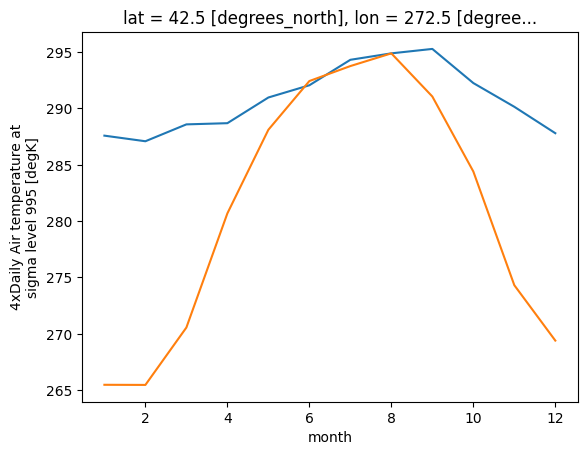

In [47]:
monthly_ds = ds.groupby("time.month").mean()
monthly_ds.sel(lat=32.7, lon=242, method='nearest').air.plot.line(label="San Diego")
monthly_ds.sel(lat=41.8, lon=360-87, method='nearest').air.plot.line(label="Chicago")

## The scientific python ecosystem

Xarray ties in to the larger scientific python ecosystem and in turn many
packages build on top of xarray. A long list of such packages is here:
<https://docs.xarray.dev/en/stable/related-projects.html>.

Now we will demonstrate some cool features.


### Pandas: tabular data structures

You can easily [convert](https://docs.xarray.dev/en/stable/pandas.html) between xarray and [pandas](https://pandas.pydata.org/) structures. This allows you to conveniently use the extensive pandas 
ecosystem of packages (like [seaborn](https://seaborn.pydata.org/)) for your work.


In [48]:
# convert to pandas dataframe
df = ds.isel(time=slice(10)).to_dataframe()
df

air
lat  time                lon          
75.0 2013-01-01 00:00:00 200.0  241.20
                         202.5  242.50
                         205.0  243.50
                         207.5  244.00
                         210.0  244.10
...                                ...
15.0 2013-01-03 06:00:00 320.0  297.00
                         322.5  297.29
                         325.0  296.90
                         327.5  296.79
                         330.0  297.10

[13250 rows x 1 columns]

In [49]:
# convert dataframe to xarray
df.to_xarray()

<xarray.Dataset> Size: 106kB
Dimensions:  (lat: 25, time: 10, lon: 53)
Coordinates:
  * lat      (lat) float32 100B 75.0 72.5 70.0 67.5 65.0 ... 22.5 20.0 17.5 15.0
  * time     (time) datetime64[ns] 80B 2013-01-01 ... 2013-01-03T06:00:00
  * lon      (lon) float32 212B 200.0 202.5 205.0 207.5 ... 325.0 327.5 330.0
Data variables:
    air      (lat, time, lon) float64 106kB 241.2 242.5 243.5 ... 296.8 297.1

### Alternative array types

This notebook has focused on Numpy arrays. Xarray can wrap [other array](https://docs.xarray.dev/en/stable/user-guide/duckarrays.html) types! For example:

<img src="https://docs.dask.org/en/stable/_images/dask_horizontal.svg" width="20%"> [distributed parallel arrays](https://docs.dask.org/en/latest/array.html) & [Xarray user guide on Dask](https://docs.xarray.dev/en/stable/user-guide/dask.html)

<img src="https://raw.githubusercontent.com/pydata/sparse/master/docs/logo.svg" width="15%"> **pydata/sparse** : [sparse arrays](https://sparse.pydata.org)

<img src="https://raw.githubusercontent.com/cupy/cupy.dev/master/images/cupy_logo.png" width="22%"> [GPU arrays](https://cupy.dev) & [cupy-xarray](https://cupy-xarray.readthedocs.io/)

<img src="https://pint.readthedocs.io/en/stable/_static/logo-full.jpg" width="10%"> **pint** : [unit-aware arrays](https://pint.readthedocs.io) & [pint-xarray](https://github.com/xarray-contrib/pint-xarray)

### Dask

Dask cuts up NumPy arrays into blocks and parallelizes your analysis code across
these blocks

<img src="https://raw.githubusercontent.com/dask/dask/main/docs/source/images/dask-array.svg" style="width:45%">


In [ ]:
# demonstrate dask dataset
dasky = xr.tutorial.open_dataset(
    "air_temperature",
    chunks={"time": 10},  # 10 time steps in each block
)

dasky.air

All computations with dask-backed xarray objects are lazy, allowing you to build
up a complicated chain of analysis steps quickly


In [ ]:
# demonstrate lazy mean
dasky.air.mean("lat")

To get concrete values, call `.compute` or `.load`


In [ ]:
# "compute" the mean
dasky.air.mean("lat").compute()